# Top-1,000 band counts: negative-binomial population scaling

## tl;dr

This model asks how many **mapped bands from the frozen top 1,000** an FUA has
relative to the count expected from its population.

- The population exponent is **1.37**
  (95% CI **1.19–1.56**;
  test against proportional scaling `β = 1`, **p = 0.0001**).
  Band counts therefore rise more than proportionally with population in this
  catalogue.
- The negative-binomial model fits materially better than Poisson on its own
  outcome: AIC **327.7** versus **369.7**;
  Poisson Pearson dispersion is **2.37**.
- **Brighton and Hove** has the largest positive standardized
  residual: 15 observed bands versus
  3.0 expected.
- **Liverpool** has 39 observed versus
  16.9 expected.
- All **83 FUAs** are retained, including **22 zero-band FUAs**.

Taken together, this is the better primary model for **scene breadth** and for
the question "how many selected bands would population predict?" It estimates
expectations for the **660 mapped bands**, not the 340 selected identities whose
origins cannot be allocated to the population universe.

## 01. Context and methods

The response is each 2021 UK Functional Urban Area's count of bands in the
frozen popularity-first top-1,000 catalogue that have a strict or
reviewed-extended FUA assignment. The model is an NB2 generalized linear model:

$$
Y_i \sim \operatorname{NB}(\mu_i, \alpha), \qquad
\log(\mu_i) = a + \beta\log(P_i).
$$

The null `β = 1` corresponds to proportional scaling. A positive residual means
the city has more mapped bands than the model expects at its population. The
NB2 variance is $\mu_i + \alpha\mu_i^2$, allowing the clustering that a Poisson
model cannot absorb.

### Assumptions

- Counts cover the frozen top 1,000 and the reviewed mapping snapshot, not a
  census of all British bands.
- Unmapped bands remain unallocated; expected counts target the 660 mapped
  observations.
- Current population is compared with bands formed across many decades.
- City residuals are descriptive associations, not causal estimates of what
  population creates.

## 02. Data

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the uk-music-cities repository root")

import sys
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from python_uk_bands.output_share import build_output_share_metrics

SNAPSHOT_ID = "20260718T204522Z"
TOP_N = 1000
BANDS_PATH = ROOT / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv"
MAPPING_AUDIT_PATH = ROOT / "data/interim/popularity_first_top1000_20260718T204522Z_fua_mapping_audit.csv"
POPULATION_PATH = ROOT / "data/processed/uk_fua_population_2021_20260718T201304Z.csv"
ARTIFACT_DIR = ROOT / "artifacts/experiments/top1000_scaling_models/20260718T204522Z"

bands = pd.read_csv(BANDS_PATH, keep_default_na=False)
mapping_audit = pd.read_csv(MAPPING_AUDIT_PATH, keep_default_na=False)
population = pd.read_csv(POPULATION_PATH, keep_default_na=False)

shares, coverage = build_output_share_metrics(
    bands,
    mapping_audit,
    population,
    included_tiers={"strict", "reviewed_extended"},
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

assert len(bands) == bands["returned_spotify_id"].nunique() == TOP_N
assert len(mapping_audit) == TOP_N
assert len(shares) == coverage["population_fuas"] == 83
assert coverage["mapped_bands"] == int(shares["band_count"].sum()) == 660
assert coverage["zero_band_fuas"] == int(shares["band_count"].eq(0).sum()) == 22

coverage_table = pd.DataFrame(
    [
        {"Measure": "Selected bands", "Value": coverage["selected_bands"]},
        {"Measure": "Mapped bands modelled", "Value": coverage["mapped_bands"]},
        {"Measure": "FUAs", "Value": coverage["population_fuas"]},
        {"Measure": "Positive-count FUAs", "Value": coverage["mapped_fuas"]},
        {"Measure": "Zero-count FUAs", "Value": coverage["zero_band_fuas"]},
    ]
)
display(coverage_table.style.hide(axis="index"))


Measure,Value
Selected bands,1000
Mapped bands modelled,660
FUAs,83
Positive-count FUAs,61
Zero-count FUAs,22


The 83-row FUA frame preserves zero counts. This is the main reason to prefer a count model over ordinary regression on `log(band_count)`.

## 03. Results

### 03.01 Fit the negative-binomial model

In [2]:
from python_uk_bands.scaling_models import (
    fit_negative_binomial_band_scaling,
    plot_negative_binomial_fit,
    plot_negative_binomial_residuals,
)

model_results, model_summary = fit_negative_binomial_band_scaling(shares)
RESULTS_PATH = ARTIFACT_DIR / "negative_binomial_fua_results.csv"
SUMMARY_PATH = ARTIFACT_DIR / "negative_binomial_model_summary.json"
model_results.to_csv(RESULTS_PATH, index=False)
with SUMMARY_PATH.open("w", encoding="utf-8") as handle:
    json.dump(model_summary, handle, indent=2, sort_keys=True)

coefficient_table = pd.DataFrame(
    [
        {
            "Population exponent β": model_summary["population_exponent_beta"],
            "95% CI low": model_summary["beta_ci_low"],
            "95% CI high": model_summary["beta_ci_high"],
            "p-value for β = 1": model_summary["beta_equals_one_p_value"],
            "NB dispersion α": model_summary["dispersion_alpha"],
        }
    ]
)
display(coefficient_table.style.hide(axis="index").format(precision=3))
display(Markdown(f"Saved `{RESULTS_PATH.relative_to(ROOT)}` and `{SUMMARY_PATH.relative_to(ROOT)}`."))


Population exponent β,95% CI low,95% CI high,p-value for β = 1,NB dispersion α
1.373,1.186,1.561,0.000,0.325


Saved `artifacts/experiments/top1000_scaling_models/20260718T204522Z/negative_binomial_fua_results.csv` and `artifacts/experiments/top1000_scaling_models/20260718T204522Z/negative_binomial_model_summary.json`.

### 03.02 Expected counts across the population range

/Users/dpradilla/dev/uk-music-cities/src/python_uk_bands/scaling_models.py:590: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


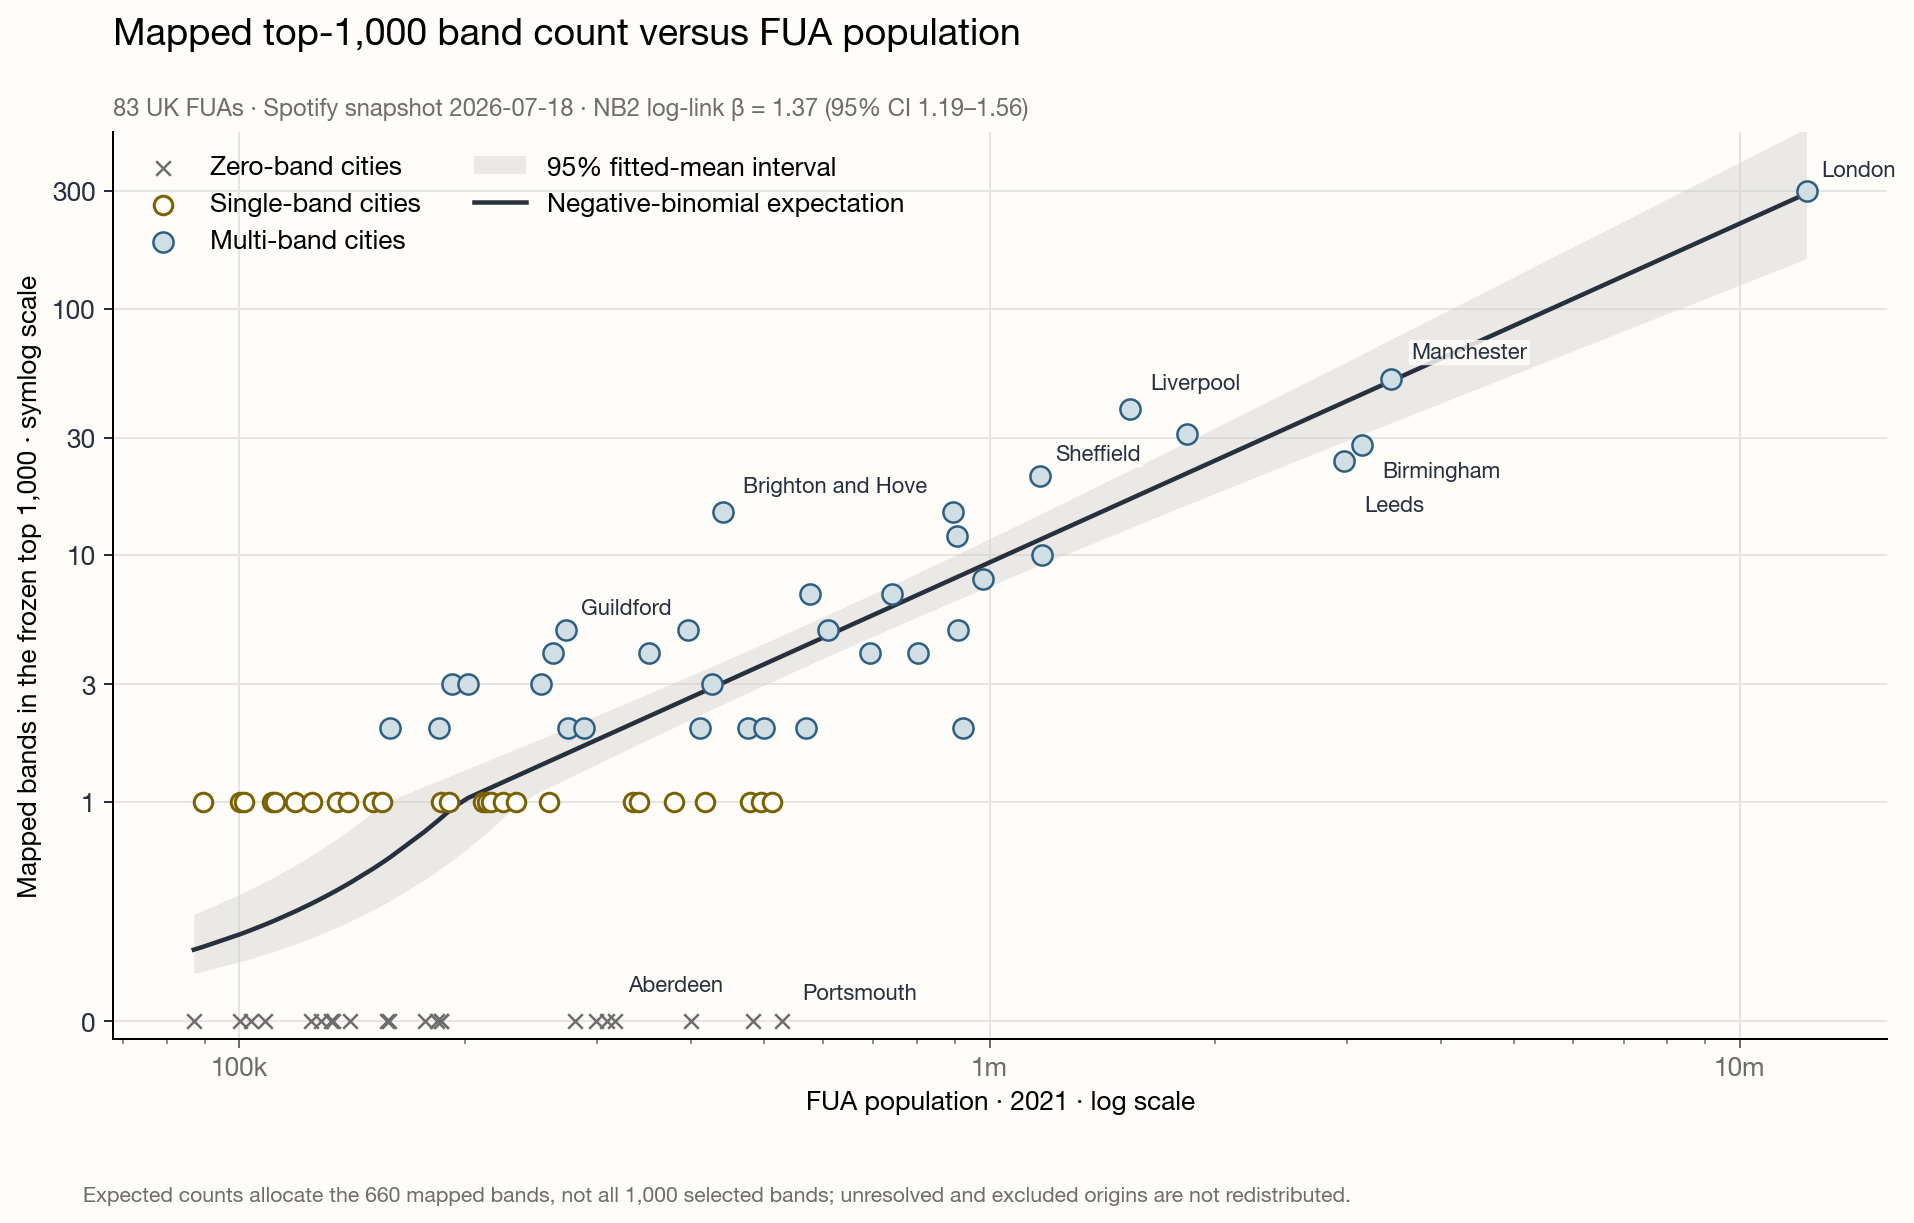

Exported to `artifacts/experiments/top1000_scaling_models/20260718T204522Z/chart_01_negative_binomial_fit.png`.

In [3]:
fit_chart_path = plot_negative_binomial_fit(
    model_results,
    model_summary,
    snapshot_date="2026-07-18",
    output_dir=ARTIFACT_DIR,
)
display(Image(filename=str(fit_chart_path)))
display(Markdown(f"Exported to `{fit_chart_path.relative_to(ROOT)}`."))


The fitted curve is the expected count under the observed scaling relationship. The y-axis uses a symlog scale so zero-count cities remain visible without adding an arbitrary pseudocount.

### 03.03 Which cities depart most from expectation?

/Users/dpradilla/dev/uk-music-cities/src/python_uk_bands/scaling_models.py:590: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


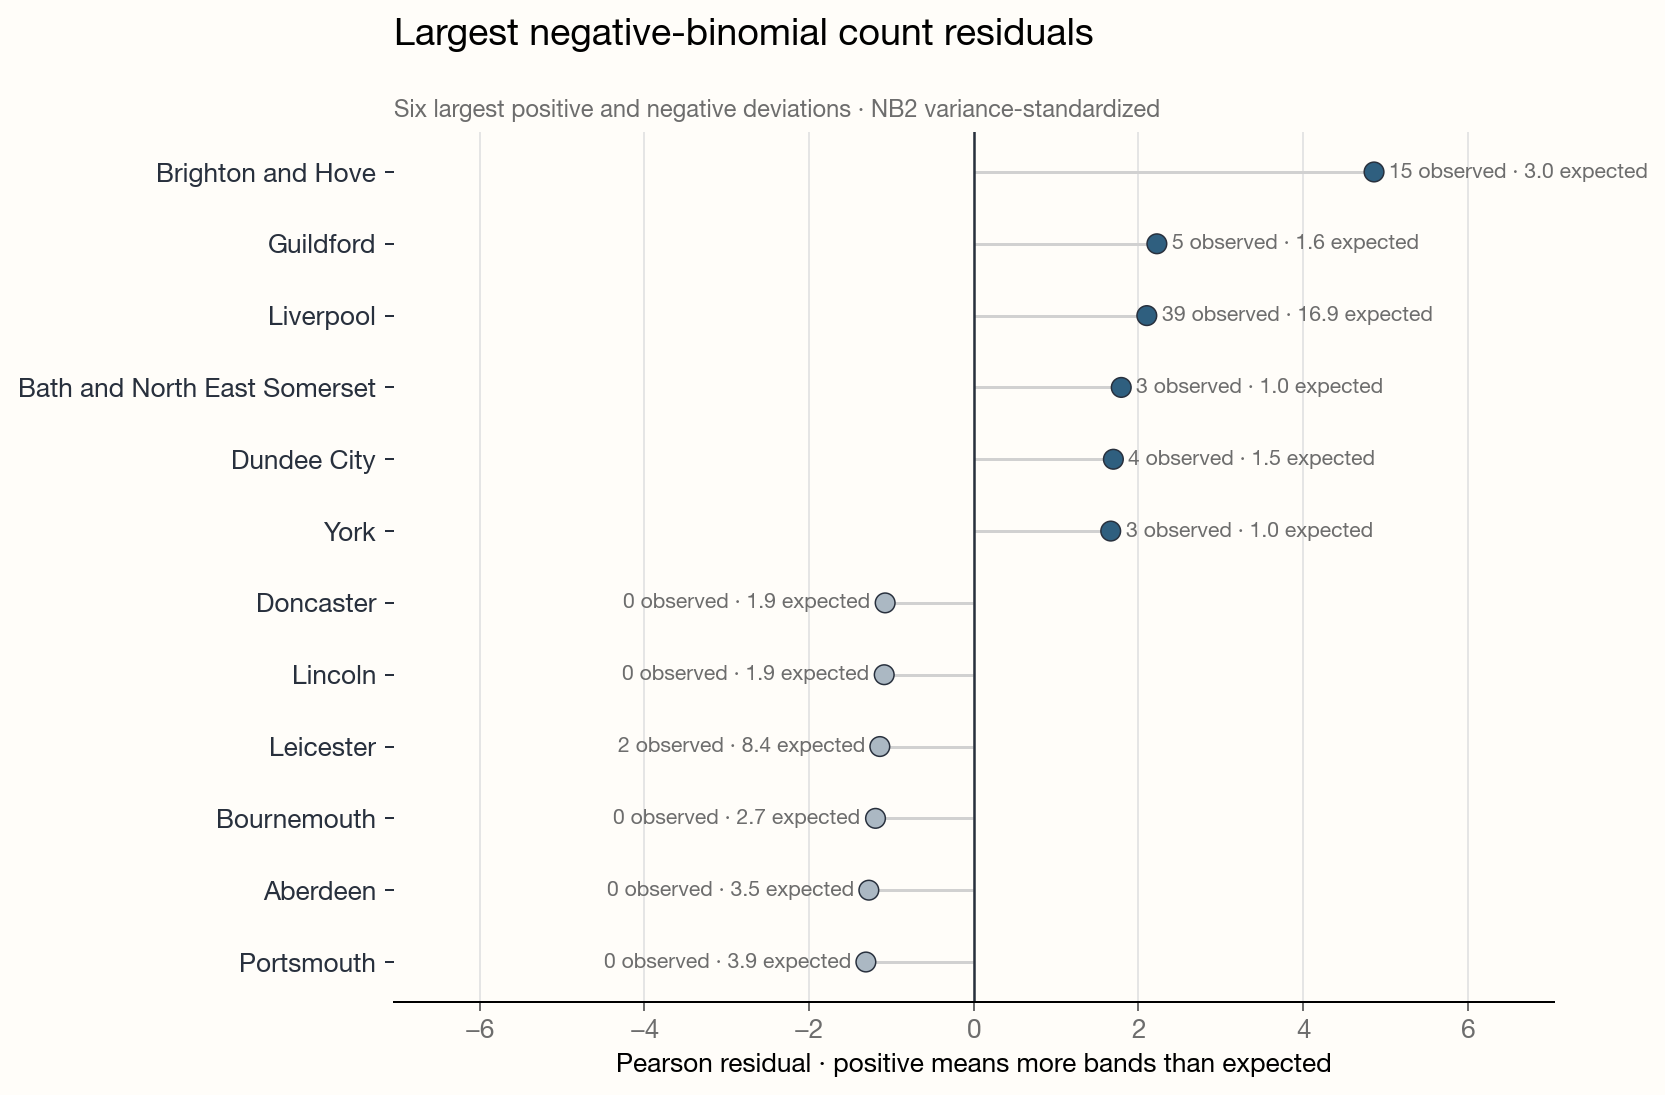

Exported to `artifacts/experiments/top1000_scaling_models/20260718T204522Z/chart_02_negative_binomial_residuals.png`.

In [4]:
residual_chart_path = plot_negative_binomial_residuals(
    model_results,
    output_dir=ARTIFACT_DIR,
)
display(Image(filename=str(residual_chart_path)))
display(Markdown(f"Exported to `{residual_chart_path.relative_to(ROOT)}`."))


In [5]:
notable_cities = [
    "London", "Manchester", "Liverpool", "Sheffield",
    "Birmingham", "Leeds", "Brighton and Hove", "Guildford",
]
notable = (
    model_results.loc[
        model_results["study_city_label"].isin(notable_cities),
        [
            "study_city_label", "population", "band_count",
            "expected_band_count", "observed_to_expected_count",
            "pearson_residual",
        ],
    ]
    .sort_values("pearson_residual", ascending=False)
    .rename(
        columns={
            "study_city_label": "FUA",
            "population": "Population",
            "band_count": "Observed bands",
            "expected_band_count": "Expected bands",
            "observed_to_expected_count": "Observed / expected",
            "pearson_residual": "Pearson residual",
        }
    )
)
display(
    notable.style.hide(axis="index").format(
        {
            "Population": "{:,.0f}",
            "Expected bands": "{:.1f}",
            "Observed / expected": "{:.2f}×",
            "Pearson residual": "{:+.2f}",
        }
    )
)


FUA,Population,Observed bands,Expected bands,Observed / expected,Pearson residual
Brighton and Hove,"441,252",15,3.0,4.93×,+4.86
Guildford,"272,893",5,1.6,3.18×,+2.22
Liverpool,"1,540,817",39,16.9,2.30×,+2.10
Sheffield,"1,168,389",21,11.6,1.81×,+1.27
Manchester,"3,432,092",52,50.9,1.02×,+0.04
London,"12,274,097",299,292.6,1.02×,+0.04
Birmingham,"3,135,994",28,44.9,0.62×,-0.64
Leeds,"2,969,034",24,41.7,0.58×,-0.72


### 03.04 Model diagnostics

In [6]:
diagnostics = pd.DataFrame(
    [
        {"Diagnostic": "Negative-binomial AIC", "Value": model_summary["aic"]},
        {"Diagnostic": "Poisson AIC", "Value": model_summary["poisson_aic"]},
        {"Diagnostic": "Poisson Pearson dispersion", "Value": model_summary["poisson_pearson_dispersion"]},
        {"Diagnostic": "McFadden pseudo-R²", "Value": model_summary["mcfadden_pseudo_r_squared"]},
        {"Diagnostic": "NB optimizer converged", "Value": model_summary["converged"]},
    ]
)
display(diagnostics.style.hide(axis="index").format({"Value": lambda value: f"{value:.3f}" if isinstance(value, float) else str(value)}))

assert model_summary["converged"]
assert model_summary["aic"] < model_summary["poisson_aic"]
assert model_summary["poisson_pearson_dispersion"] > 1
assert abs(model_summary["population_exponent_beta"] - 1.3731180408565902) < 1e-10
assert int(model_results["band_count"].sum()) == coverage["mapped_bands"]


Diagnostic,Value
Negative-binomial AIC,327.721
Poisson AIC,369.727
Poisson Pearson dispersion,2.372
McFadden pseudo-R²,0.279
NB optimizer converged,True


## 04. Takeaways

1. Counts scale superlinearly in this catalogue. The fitted
   exponent is 1.37, and its interval does
   not include proportional scaling at `β = 1`.
2. Negative binomial fits better than Poisson. The AIC improvement and
   Poisson dispersion of 2.37 confirm
   meaningful overdispersion.
3. Expected count is not a recommended catalogue size. It is the number of
   mapped top-1,000 bands predicted for each FUA given the fixed catalogue.
4. Residuals are the model-adjusted "punching above weight" measure. They
   replace the chart's assumed 1:1 baseline with an empirically estimated
   population relationship.
5. This is the stronger primary model for scene breadth. The separate
   log–log notebook remains useful for audience reach, but it answers a
   different question and drops zero-output FUAs.

### 04.01 Status

The model is validated and retains the full FUA universe. Catalogue selection,
incomplete origin mapping and the
current-versus-historical population mismatch prevent causal or definitive
claims about British music production.